# Implementation of the elicitation procedure 

In [1]:
import os
import sys

sys.path.append("../")

import matplotlib.pyplot as plt
import numpy as np

In [2]:
from python.decision_maker import DecisionMaker, HiddenDecisionMakers
from python.query import NeighboringRectanglesQuery, SingleRectangleQuery
from python.identify import UTAsIdentification

### Drawing Random Decision Makers whose value functions are piecewise linear and increasing (UTAs)

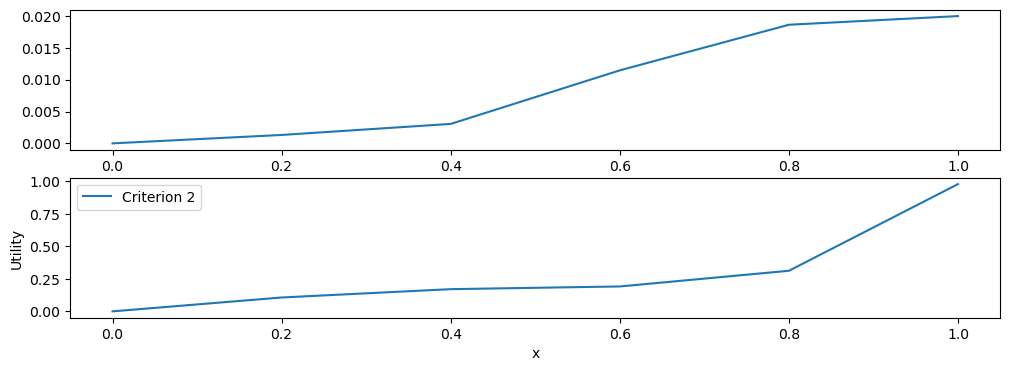

In [3]:
# Draw and plot a DM with a value function with 2 criteria and 5 pieces
single_dm = DecisionMaker(n_criteria=2, n_pieces=5)
single_dm.plot_decision_function()

DM1:


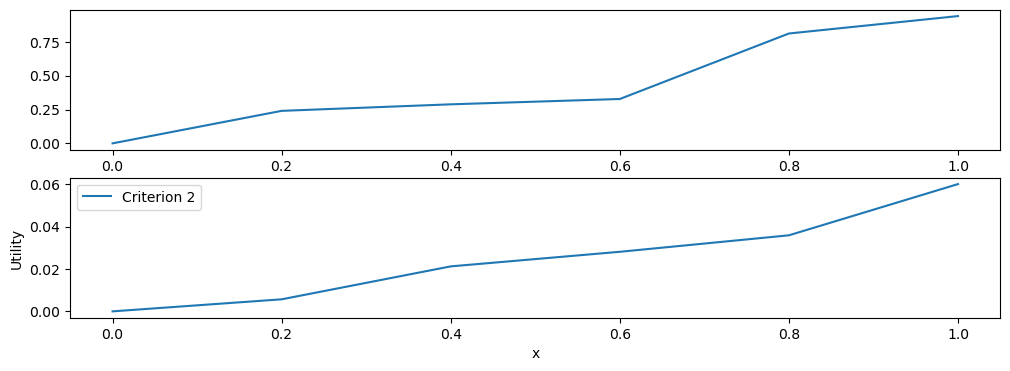

DM2:


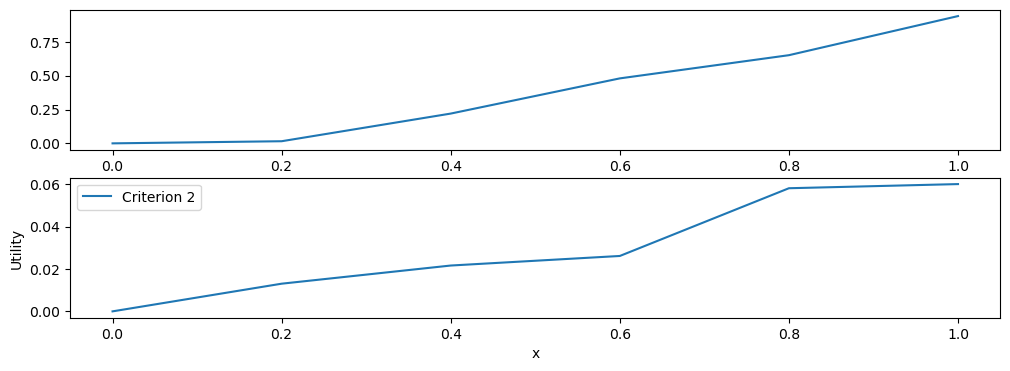

In [4]:
# Draw 2 Hidden Decision Makers with value functions with 2 criteria and 10 pieces

hdm = HiddenDecisionMakers(n_dms=2, n_criteria=2, n_pieces=5)
print("DM1:")
hdm.dms[0].plot_decision_function()
print("DM2:")
hdm.dms[1].plot_decision_function()

In [5]:
print("DM1 slopes:", hdm.dms[0].coefficients)
print("DM2 slopes:", hdm.dms[1].coefficients)

DM1 slopes: [[0.         0.24003841 0.2882792  0.3276746  0.81142676 0.94      ]
 [0.         0.005679   0.0212046  0.0280824  0.0358518  0.06      ]]
DM2 slopes: [[0.         0.0157356  0.21996    0.47989818 0.6512132  0.94      ]
 [0.         0.0130446  0.0216042  0.0261126  0.0580446  0.06      ]]


## Identification

In [6]:
# Instantiate identification class
identif = UTAsIdentification(n_criteria=2, n_pieces=5)
# Identify
elicited_coefficients = identif.identify_hdms(hdms=hdm)

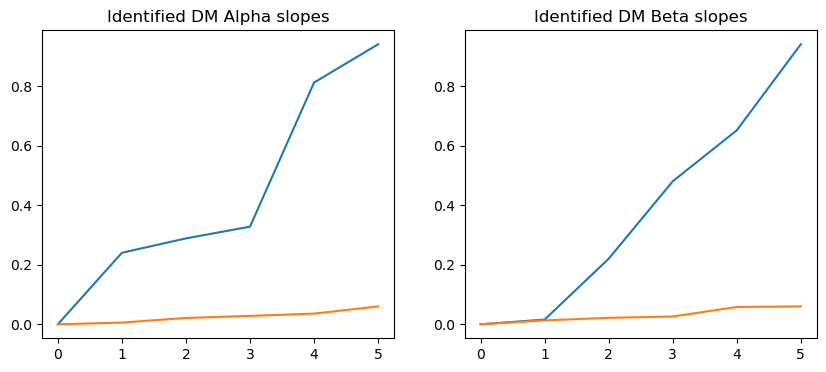

Ground Truth Value Functions:


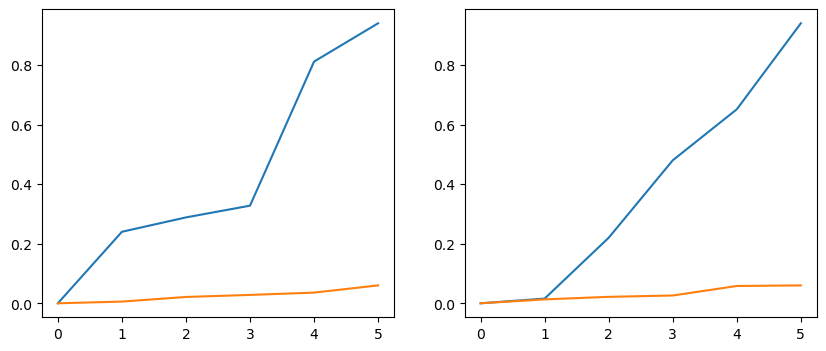

In [7]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(elicited_coefficients["alpha"][0])
plt.title("Identified DM Alpha slopes")
plt.plot(elicited_coefficients["alpha"][1])

plt.subplot(1, 2, 2)
plt.plot(elicited_coefficients["beta"][0])
plt.plot(elicited_coefficients["beta"][1])
plt.title("Identified DM Beta slopes")
plt.show()


print("Ground Truth Value Functions:")
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(hdm.dms[0].coefficients[0])
plt.plot(hdm.dms[0].coefficients[1])
plt.subplot(1, 2, 2)
plt.plot(hdm.dms[1].coefficients[0])
plt.plot(hdm.dms[1].coefficients[1])
plt.show()